# **Franck-Hertz Experiment with Neon**

This notebook documents the **Franck-Hertz Experiment**, which provides evidence of discrete atomic energy levels by studying inelastic collisions between electrons and neon atoms.

### **Objectives:**
- Record a **Franck-Hertz curve** for neon.
- Measure the energy absorbed by neon atoms due to inelastic collisions.
- Identify the energy levels involved in electron-atom interactions.
- Compare experimental energy values with theoretical energy levels of neon.


## **Theoretical Background**
The **Franck-Hertz Experiment** is a fundamental experiment in quantum mechanics that demonstrates the quantized nature of atomic energy levels.

**Key Concepts:**
- Electrons are accelerated through a low-pressure neon-filled discharge tube.
- As electrons collide with neon atoms, two types of collisions occur:
  1. **Elastic Collisions**: Electrons retain their kinetic energy and change direction.
  2. **Inelastic Collisions**: Electrons transfer energy to neon atoms, exciting them to higher energy levels.

**Observation:**
At specific accelerating voltages \( U_1 \), electrons gain sufficient kinetic energy to excite neon atoms. When this occurs, electrons lose energy, causing a **drop in current** measured at the anode. This leads to **periodic minima** in the current vs voltage graph.

The energy difference between two successive minima corresponds to the **excitation energy** of neon atoms:

$$ E_{exc} = e \cdot \Delta U_1 $$

where \( e \) is the elementary charge and \( \Delta U_1 \) is the voltage difference between two minima.


## **Experimental Setup**

![Setup](imgs/image.png)

The Franck-Hertz experimental setup includes:
- A **discharge tube** filled with low-pressure neon.
- An **electron source** (heated cathode) emitting electrons.
- A **set of electrodes** to accelerate and collect electrons.
- A **variable voltage source** \( U_1 \) controlling electron acceleration.
- A **measurement system** recording the anode current \( I_A \) as a function of \( U_1 \).

### **Procedure:**
1. Increase \( U_1 \) from 0V to 99V while keeping control voltages \( U_2 \) and \( U_3 \) constant.
2. Record the anode current \( I_A \) as a function of \( U_1 \).
3. Identify the voltage values corresponding to minima in the current.
4. Compute the excitation energy of neon based on voltage differences between successive minima.


## **Data Analysis & Calculations**
1. **Identify Minima in the Current-Voltage Curve:**
   - Extract voltage values corresponding to minima in \( I_A \).
   - Compute the voltage differences \( $\Delta U_1$ \) between successive minima.

2. **Calculate Excitation Energy:**
   - Using the equation:

     $$ E_{exc} = e \cdot \Delta U_1 $$

   - Convert to **electron volts (eV)** and compare with theoretical values.

3. **Plot Data:**
   - Generate a plot of **anode current vs accelerating voltage**.
   - Highlight the minima and fit a trend line.

4. **Determine Atomic Transitions:**
   - Compare measured energy values with known **neon excitation levels (3s, 3p states)**.
   - Estimate emitted **photon wavelength** for transitions using:

     $$ \lambda = \frac{hc}{E_{exc}} $$

   - Identify the **visible light emission** from neon (typically orange-red fluorescence).



--- Linear Fit Results ---
Slope for first 3 points: 17.160 V per index unit
Slope for last 3 points: 17.695 V per index unit


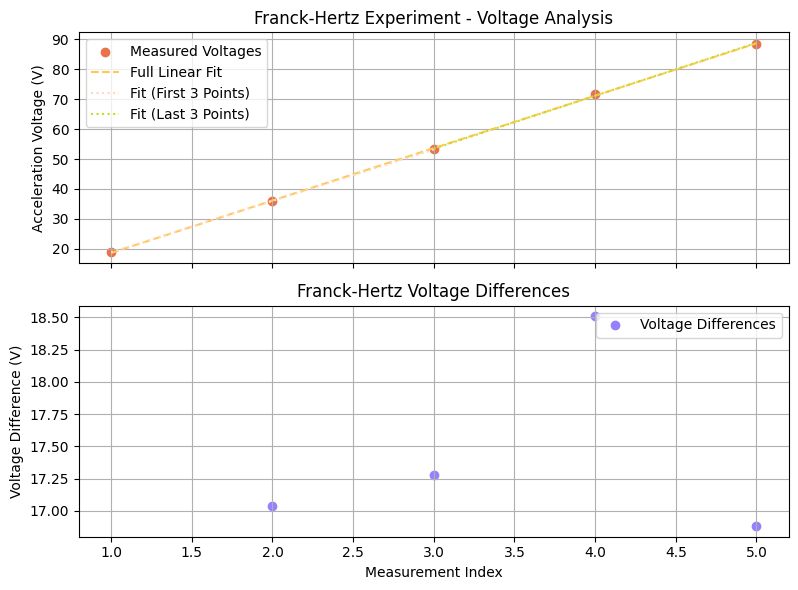

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Experimental Data
index = np.arange(1, 6)  # Measurement index
voltages = np.array([18.86, 35.9, 53.18, 71.69, 88.57])  # Measured acceleration voltages

# Voltage differences between successive minima
voltage_differences = np.array([17.038, 17.28, 18.51, 16.88])
index_differences = np.arange(2, 6)  # Corresponding indices for differences

def perform_linear_fit(x, y):
    """
    Perform linear regression (least squares polynomial fit) for given x and y values.
    
    Parameters:
        x (array): X values (independent variable).
        y (array): Y values (dependent variable).
    
    Returns:
        tuple: Fitted polynomial coefficients and polynomial function.
    """
    coefficients = np.polyfit(x, y, 1)  # Linear fit (1st degree polynomial)
    trend_function = np.poly1d(coefficients)
    return coefficients, trend_function

def main():
    """Main function to analyze Franck-Hertz voltage data."""
    
    # Compute linear fits
    full_fit_coeffs, full_trend = perform_linear_fit(index, voltages)
    first3_fit_coeffs, first3_trend = perform_linear_fit(index[:3], voltages[:3])
    last3_fit_coeffs, last3_trend = perform_linear_fit(index[2:], voltages[2:])

    # Print computed slopes
    print("\n--- Linear Fit Results ---")
    print(f"Slope for first 3 points: {first3_fit_coeffs[0]:.3f} V per index unit")
    print(f"Slope for last 3 points: {last3_fit_coeffs[0]:.3f} V per index unit")

    # Plotting results
    fig, axs = plt.subplots(2, figsize=(8, 6), sharex=True)

    # First plot: Measured voltages with trend lines
    axs[0].scatter(index, voltages, color="#E9724C", label="Measured Voltages")
    axs[0].plot(index, full_trend(index), color="#FFC857", linestyle="dashed", label="Full Linear Fit")
    axs[0].plot(index[:3], first3_trend(index[:3]), color="#FFD8BE", linestyle="dotted", label="Fit (First 3 Points)")
    axs[0].plot(index[2:], last3_trend(index[2:]), color="#C1DF1F", linestyle="dotted", label="Fit (Last 3 Points)")
    axs[0].set_ylabel("Acceleration Voltage (V)")
    axs[0].set_title("Franck-Hertz Experiment - Voltage Analysis")
    axs[0].legend()
    axs[0].grid(True)

    # Second plot: Voltage differences
    axs[1].scatter(index_differences, voltage_differences, color="#9381FF", label="Voltage Differences")
    axs[1].set_xlabel("Measurement Index")
    axs[1].set_ylabel("Voltage Difference (V)")
    axs[1].set_title("Franck-Hertz Voltage Differences")
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()
